#Linear Regression From Scratch.

Implemented using **NumPy** — **Pandas** and **Matplotlib** are just for data setup and visualization.

In this notebook we implement **Linear Regression from scratch**, covering:
- Simple Linear Regression (one feature)
- Multiple Linear Regression (many features)
- The Cost Function (Mean Squared Error)
- Gradient Descent (the optimization loop)


Resources that helped me to  build this:


Video 1 — Intuition : https://youtu.be/7ArmBVF2dCs?si=eehDfUU4AaDxNwDJ

Video 2 — Implementation : https://youtu.be/Jj7WD71qQWE?si=7uzoHTNz8bM445Lb

Wikipedia — https://en.wikipedia.org/wiki/Simple_linear_regression

#What is linear regression ?

Linear regression is a model that tries to find `linear relationship` between some input `features` X and output `label` y.

The goal is simple ▶ find the `best fitting line ` that produces the smallest possible difference between the `predicted` and `actual` output.

Mathematically it's just a simple line:     y ​= wX + b



where:
- $X$ → input feature(s)
- $\hat{y}$ → the predicted output (label)
- $w$ → the **weight** (slope) — how much $X$ influences $y$
- $b$ → the **bias** (intercept) — the baseline when $X = 0$

We cover `two cases`

**Simple LR** - one input feature:
$$\hat{y} = w \cdot x + b$$

**Multipe LR** - many input features :     
$$\hat{y} = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = \mathbf{w}^T \mathbf{X} + b$$

-- Althought it seems the two types are not that similar but we will be using the same techniques to reach the same goal.

Let's start coding 🤓.





##  1. Imports

In [1]:
import numpy as np ## all the math - matrix ops.
import pandas as pd ## loading and exploring our data
import matplotlib.pyplot as plt ## visualization -- bacoming one with the data --

##  2. Initialize Data

we create two simple datasets using **Numpy**

`dataset_01` : One input feature `X`, one output `y`
Example ▶ *hours studied → exam score*.

`dataset_02` : Multiple input features, `X`, one output `y`
Example ▶ *size + rooms + location → house price*




simple dataset shape : (100, 2)
          X          y
0  0.749080   6.278670
1  1.901429  10.340696
2  1.463988   8.706320
3  1.197317   8.100522
4  0.312037   5.843678


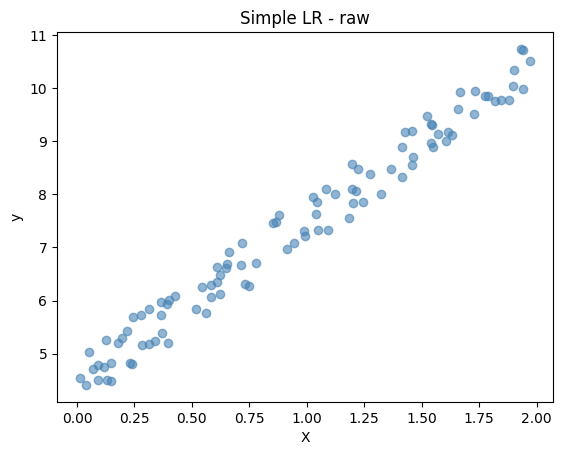

multi dataset shape : (100, 4)
         X1        X2        X3          y
0  0.642032  0.084140  0.161629  15.918297
1  0.898554  0.606429  0.009197  18.834359
2  0.101472  0.663502  0.005062  14.799798
3  0.160808  0.548734  0.691895  14.226194
4  0.651961  0.224269  0.712179  15.549077


In [2]:
np.random.seed(42)

# ---- creating the first dataset

m_simple = 100
X_simple = 2 * np.random.rand(m_simple) # shape(100,)
y_simple = 4 + 3 * X_simple + np.random.rand(m_simple) # y = 3X + 4

df_simple = pd.DataFrame({"X":X_simple,
                          "y" :y_simple})
print(f"simple dataset shape : {df_simple.shape}")
print(df_simple.head())

## a bit of visualization
plt.scatter(X_simple, y_simple, alpha=0.6, c="steelblue")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Simple LR - raw")
plt.show()


# ---- creating the second dataset
m_multi = 100
X_multi = np.random.rand(m_multi, 3) # shape(100,3)
true_w = np.array([5.0, 3.0, -1.5])
true_b = 12.0
y_multi = X_multi @ true_w + true_b + np.random.rand(m_multi) # y = Xw + b

df_multi = pd.DataFrame(X_multi,
                        columns=["X1", "X2", "X3"])
df_multi["y"] = y_multi
print(f"multi dataset shape : {df_multi.shape}")
print(df_multi.head())

##  3. The Cost Function — MSE

We need to measure the **difference between true and predicted labels**..
For that we can use the **Mean Squared Error(MSE)** function  :

$$J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right)^2$$

where:
- $m$ → number of training samples
- $\hat{y}^{(i)}$ → predicted value for sample $i$
- $y^{(i)}$ → actual value for sample $i$
- the $\frac{1}{2}$ is just a math convenience — it cancels out nicely when we take the derivative

The higher $J$ is, the worse our line fits the data. Our entire job is to **drive $J$ down**.


In [3]:
def compute_cost(X, y, w, b):
  """
  MSE cost function.
  works for both simple and multipe LR.
  """

  m = len(y)
  y_pred = X @ w + b if X.ndim == 2 else X * w + b
  cost = (1 / (2 * m)) * np.sum((y_pred - y) **2)
  return cost

## 4. Gradient Descent

Now that we can measure the error we need a way to **reduce it**

One of the techniques we can use is called **Gradient Descent**

https://youtu.be/IHZwWFHWa-w?si=RC0adxqNHgD7AUd4

`

That's gradient descent — we take small steps in the direction that decreases $J$ the most, by following the **negative gradient**.

The update rules are:

$$w := w - \alpha \cdot \frac{\partial J}{\partial w}$$

$$b := b - \alpha \cdot \frac{\partial J}{\partial b}$$

where $\alpha$ is the **learning rate** — how big each step is.

Taking the partial derivatives of $J$:

$$\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right) \cdot x^{(i)}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right)$$

We repeat these updates for a fixed number of iterations (epochs) until the cost stops dropping.



## 5. The Gradient Function

Here we just implement the gradient computation as a function.

It takes the current weights, bias, features, and labels -- and returns `dw` and `db` the two values that we need to update our parameters.

This function is suitable for both types of LR the only thing that differs is the shape of both **X** and **w**.


In [4]:
def compute_gradients(X, y, w, b):
  """
  Computes dw and db for one gradient step.
  works for both simple and multipe LR.
  """
  m = len(y)
  y_pred = X @ w + b if X.ndim == 2 else X * w + b
  error = y_pred - y #shape (m,)

  if X.ndim == 2:
    dw = (1 / m) * (X.T @ error)
  else:
    dw = (1 / m) * np.dot(X, error)

  db = (1 / m) * np.sum(error)

  return dw, db

## 6. Simple Linear Regression

Now we put it all together for the **one-feature case**.

We write a `SimpleLinearRegression` class  that:
1. Initializes $w$ and $b$ to zero
2. Runs the gradient descent loop for `n_epochs` iterations
3. At each step: computes the prediction → computes the cost → computes the gradients → updates $w$ and $b$
4. Tracks the cost over time so we can plot the learning curve

At the end of training, $w$ and $b$ hold the best line we found.


In [5]:
class SimpleLinearRegression:
  def __init__(self,
               lr=0.01,
               n_epochs=1000):
    self.lr = lr
    self.n_epochs = n_epochs
    self.w = 0
    self.b = 0
    self.cost_history = []

  def fit(self, X, y):
    self.w = 0.0
    self.b = 0.0
    self.cost_history =[]

    for epoch in range(self.n_epochs):
      dw, db = compute_gradients(X, y, self.w, self.b)
      self.w -= self.lr * dw
      self.b -= self.lr * db

      cost = compute_cost(X, y, self.w, self.b)
      self.cost_history.append(cost)

      if epoch%100 == 0:
        print(f"Epoch {epoch:4d} | Cost: {cost:.4f} | w: {self.w:.4f} | b: {self.b:.4f}")

    return self

  def predict(self, X):
    return X *self.w + self.b

## 7. Test - Simple Lr

We train a model on our simple dataset and check for two things:
1.**Cost curve** -  does the loss go down smoothly for each epoch
2.**Regression line** - we plot the learned line over the raw data points. Does it actually fit.


Epoch    0 | Cost: 17.9449 | w: 0.7928 | b: 0.7319
Epoch  100 | Cost: 0.0478 | w: 3.1488 | b: 4.3261
Epoch  200 | Cost: 0.0427 | w: 3.0131 | b: 4.4797
Epoch  300 | Cost: 0.0425 | w: 2.9886 | b: 4.5075
Epoch  400 | Cost: 0.0425 | w: 2.9842 | b: 4.5125

Learned  →  w: 2.9834  |  b: 4.5134
True     →  w: 3.0000  |  b: 4.0000


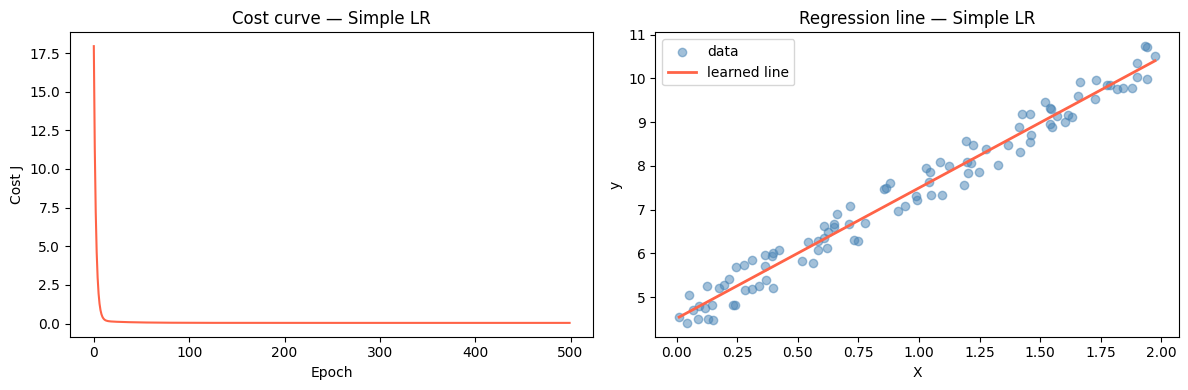

In [6]:
model_simple = SimpleLinearRegression(lr=0.1, n_epochs=500)
model_simple.fit(X_simple, y_simple)

print(f"\nLearned  →  w: {model_simple.w:.4f}  |  b: {model_simple.b:.4f}")
print(f"True     →  w: 3.0000  |  b: 4.0000")

# --- Plot 1 : Cost curve ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(model_simple.cost_history, color="tomato")
plt.xlabel("Epoch")
plt.ylabel("Cost J")
plt.title("Cost curve — Simple LR")

# --- Plot 2 : Regression line ---
plt.subplot(1, 2, 2)
X_line = np.linspace(X_simple.min(), X_simple.max(), 100)
y_line = model_simple.predict(X_line)

plt.scatter(X_simple, y_simple, alpha=0.5, color="steelblue", label="data")
plt.plot(X_line, y_line, color="tomato", linewidth=2, label="learned line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Regression line — Simple LR")
plt.legend()

plt.tight_layout()
plt.show()

## 8. Multiple Linear Regression

The math is exactly the same — the only change is that $w$ is now a **vector** and $X$ is a **matrix**.

The prediction becomes a dot product:

$$\hat{y} = X \cdot w + b$$

where $X$ has shape $(m, n)$ — $m$ samples, $n$ features — and $w$ has shape $(n,)$.

NumPy handles this with `X @ w` (matrix multiplication), so the code barely changes from the simple case.

We adapt the gradient function and the training loop to work in this vectorized form.

In [7]:
class MultipleLinearRegression:
  def __init__(self,
               lr=0.01,
               n_epochs=1000):
    self.lr = lr
    self.n_epochs = n_epochs
    self.w = None
    self.b = 0
    self.cost_history = []

  def fit(self, X, y):
    m, n = X.shape
    self.w = np.zeros(n)
    self.b = 0.0
    self.cost_history = []

    for epoch in range(self.n_epochs):
      dw, db = compute_gradients(X, y, self.w, self.b)
      self.w -= self.lr * dw
      self.b -= self.lr * db

      cost = compute_cost(X, y, self.w, self.b)
      self.cost_history.append(cost)

      if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Cost: {cost:.4f} | w: {self.w} | b: {self.b}")

    return self

  def predict(self, X):
    return X @ self.w + self.b

## ✅ 9. Test — Multiple LR

We run the same test as before.

Epoch    0 | Cost: 83.6236 | w: [0.7692604  0.86715449 0.814218  ] | b: 1.5634451554018216
Epoch  100 | Cost: 0.5003 | w: [5.2409665  4.1933455  1.70217582] | b: 9.964451381851323
Epoch  200 | Cost: 0.1851 | w: [5.44547351 3.77269747 0.29536229] | b: 10.883541093213188
Epoch  300 | Cost: 0.0917 | w: [ 5.38960234  3.50279911 -0.41522334] | b: 11.457420100439126
Epoch  400 | Cost: 0.0601 | w: [ 5.28532536  3.33584686 -0.79510528] | b: 11.813108938598116

Learned  w: [ 5.19495444  3.23502779 -1.00608284]
True     w: [ 5.   3.  -1.5]
Learned  b: 12.0310  |  True b: 12.0


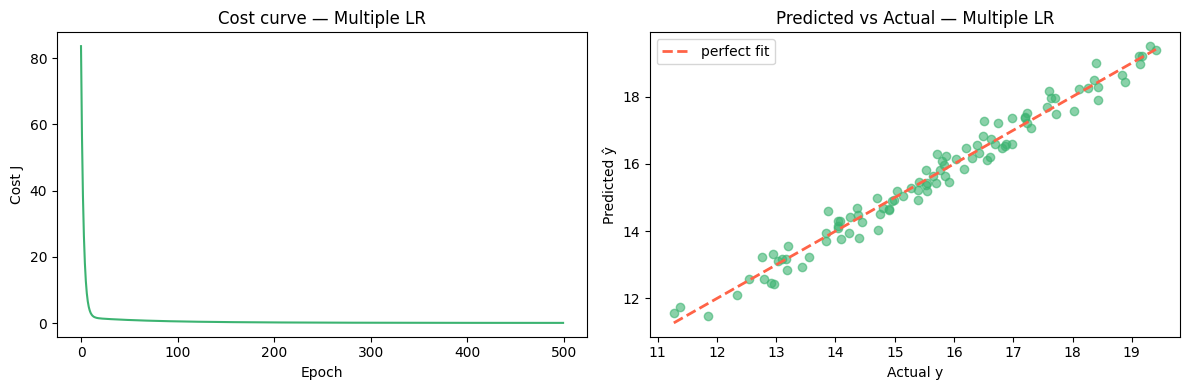

In [8]:
model_multi = MultipleLinearRegression(lr=0.1, n_epochs=500)
model_multi.fit(X_multi, y_multi)

print(f"\nLearned  w: {model_multi.w}")
print(f"True     w: {true_w}")
print(f"Learned  b: {model_multi.b:.4f}  |  True b: {true_b}")

# --- Plot 1 : Cost curve ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(model_multi.cost_history, color="mediumseagreen")
plt.xlabel("Epoch")
plt.ylabel("Cost J")
plt.title("Cost curve — Multiple LR")

# --- Plot 2 : Predicted vs Actual ---
plt.subplot(1, 2, 2)
y_pred_multi = model_multi.predict(X_multi)

plt.scatter(y_multi, y_pred_multi, alpha=0.6, color="mediumseagreen")
plt.plot(
    [y_multi.min(), y_multi.max()],
    [y_multi.min(), y_multi.max()],
    color="tomato", linewidth=2, linestyle="--", label="perfect fit"
)
plt.xlabel("Actual y")
plt.ylabel("Predicted ŷ")
plt.title("Predicted vs Actual — Multiple LR")
plt.legend()

plt.tight_layout()
plt.show()